# 02. EDA de Enriquecimiento con IMDb

Este notebook extiende el preprocesamiento base para medir cobertura del join con IMDb y detectar qué metadatos aportan mayor valor al sistema híbrido.


In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

from src.utils.recsys_utils import build_movies_enriched, ensure_dir, load_clean_data

imdb, movielens = load_clean_data(source="both", use_cache=True)
reports_dir = ensure_dir(ROOT / 'reports')
figures_dir = ensure_dir(reports_dir / 'figures')
tables_dir = ensure_dir(reports_dir / 'tables')


[20:31:56] INFO - Iniciando pipeline de carga y limpieza | source=both | use_cache=True | refresh_cache=False
[20:31:56] INFO - Cargando cache limpia para imdb
[20:32:12] INFO - Cache cargada: name.basics.pkl | filas=15257687 columnas=8
[20:34:30] INFO - Cache cargada: title.akas.pkl | filas=55865762 columnas=10
[20:35:00] INFO - Cache cargada: title.basics.pkl | filas=12446644 columnas=10
[20:35:06] INFO - Cache cargada: title.crew.pkl | filas=12446644 columnas=5
[20:35:07] INFO - Cache cargada: title.episode.pkl | filas=9612089 columnas=4
[20:35:23] INFO - Cache cargada: title.principals.pkl | filas=99029989 columnas=6
[20:35:23] INFO - Cache cargada: title.ratings.pkl | filas=1662797 columnas=3
[20:35:23] INFO - Cargando cache limpia para movielens
[20:35:23] INFO - Cache cargada: links.pkl | filas=87585 columnas=4
[20:35:23] INFO - Cache cargada: movies.pkl | filas=87585 columnas=6
[20:35:23] INFO - Cache cargada: ratings.pkl | filas=32000204 columnas=4
[20:35:23] INFO - Cache carg

In [2]:
import time
start = time.time()
items = build_movies_enriched(imdb, movielens, use_cache=True)
end = time.time()
print(f'Tiempo de build/carga de items: {end - start:.2f} segundos')

[20:35:23] INFO - Construyendo tabla enriquecida de peliculas
[20:42:35] INFO - Guardando tabla enriquecida en cache: data/processed/cache/artifacts/movies_enriched.parquet
[20:42:36] INFO - Tabla enriquecida construida | filas=87585 columnas=22


Tiempo de build/carga de items: 435.41 segundos


## Cobertura del join MovieLens-IMDb

Se revisa qué tan completa quedó la unión vía `links.csv` y `tconst`.


In [3]:
coverage_report = pd.DataFrame([
    {'metric': 'movies_catalog', 'value': len(items)},
    {'metric': 'with_tconst', 'value': items['tconst'].notna().sum()},
    {'metric': 'with_imdb_title', 'value': items['primaryTitle'].notna().sum()},
    {'metric': 'with_imdb_rating', 'value': items['averageRating'].notna().sum()},
    {'metric': 'with_runtime', 'value': items['runtimeMinutes'].notna().sum()},
]).assign(share=lambda df: df['value'] / len(items))
display(coverage_report)
coverage_report.to_csv(tables_dir / 'imdb_join_coverage.csv', index=False)


,metric,value,share
0,movies_catalog,87585,1.000000
1,with_tconst,87585,1.000000
2,with_imdb_title,87359,0.997420
3,with_imdb_rating,87223,0.995867
4,with_runtime,86894,0.992111


## Distribución de tipos, duración y año

Esto ayuda a decidir si conviene filtrar sólo a `movie` o trabajar con todo el catálogo vinculado.


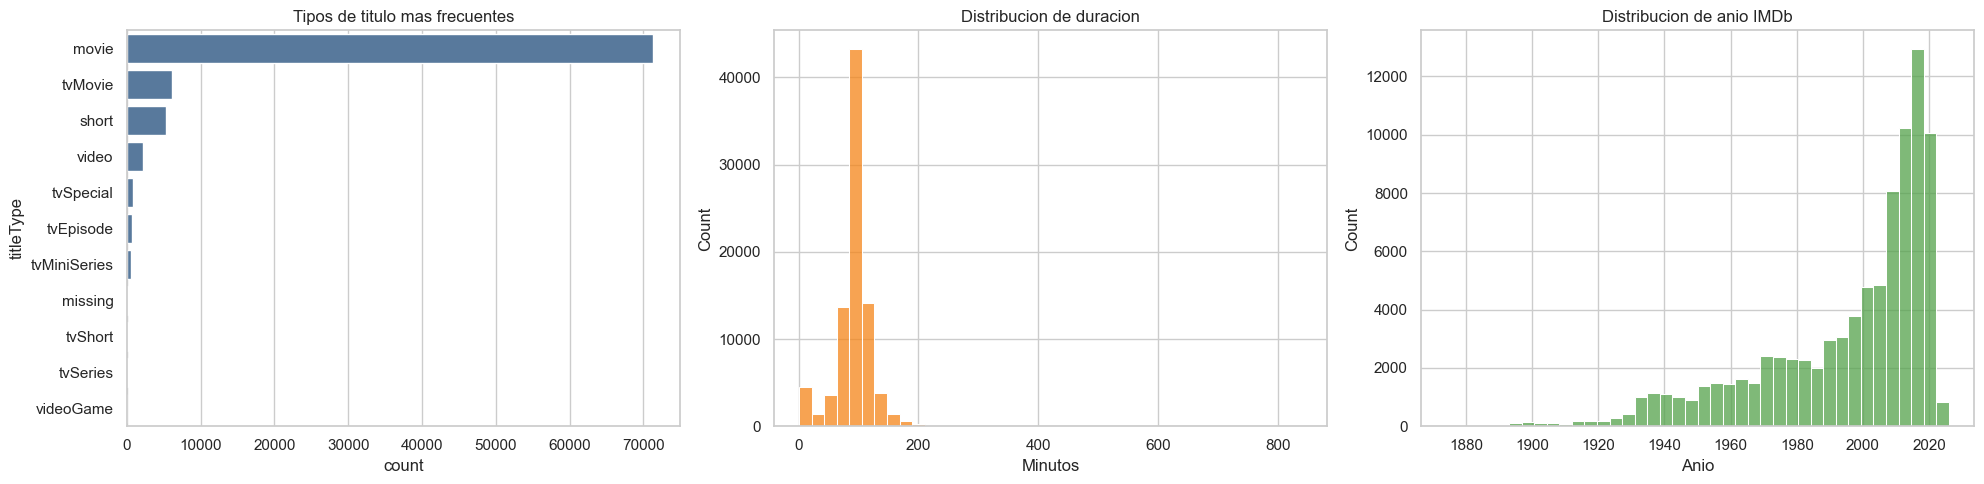

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

title_types = items['titleType'].fillna('missing').value_counts().head(12).reset_index()
title_types.columns = ['titleType', 'count']
sns.barplot(data=title_types, x='count', y='titleType', ax=axes[0], color='#4C78A8')
axes[0].set_title('Tipos de titulo mas frecuentes')

sns.histplot(items['runtimeMinutes'].dropna(), bins=40, ax=axes[1], color='#F58518')
axes[1].set_title('Distribucion de duracion')
axes[1].set_xlabel('Minutos')

sns.histplot(items['startYear'].dropna(), bins=40, ax=axes[2], color='#54A24B')
axes[2].set_title('Distribucion de anio IMDb')
axes[2].set_xlabel('Anio')

plt.tight_layout()
plt.savefig(figures_dir / 'eda_imdb_type_runtime_year.png', bbox_inches='tight')
plt.show()


## Comparar géneros y señales de personas

Aquí se analizan géneros IMDb vs MovieLens y la cobertura de directores, guionistas y cast principal.


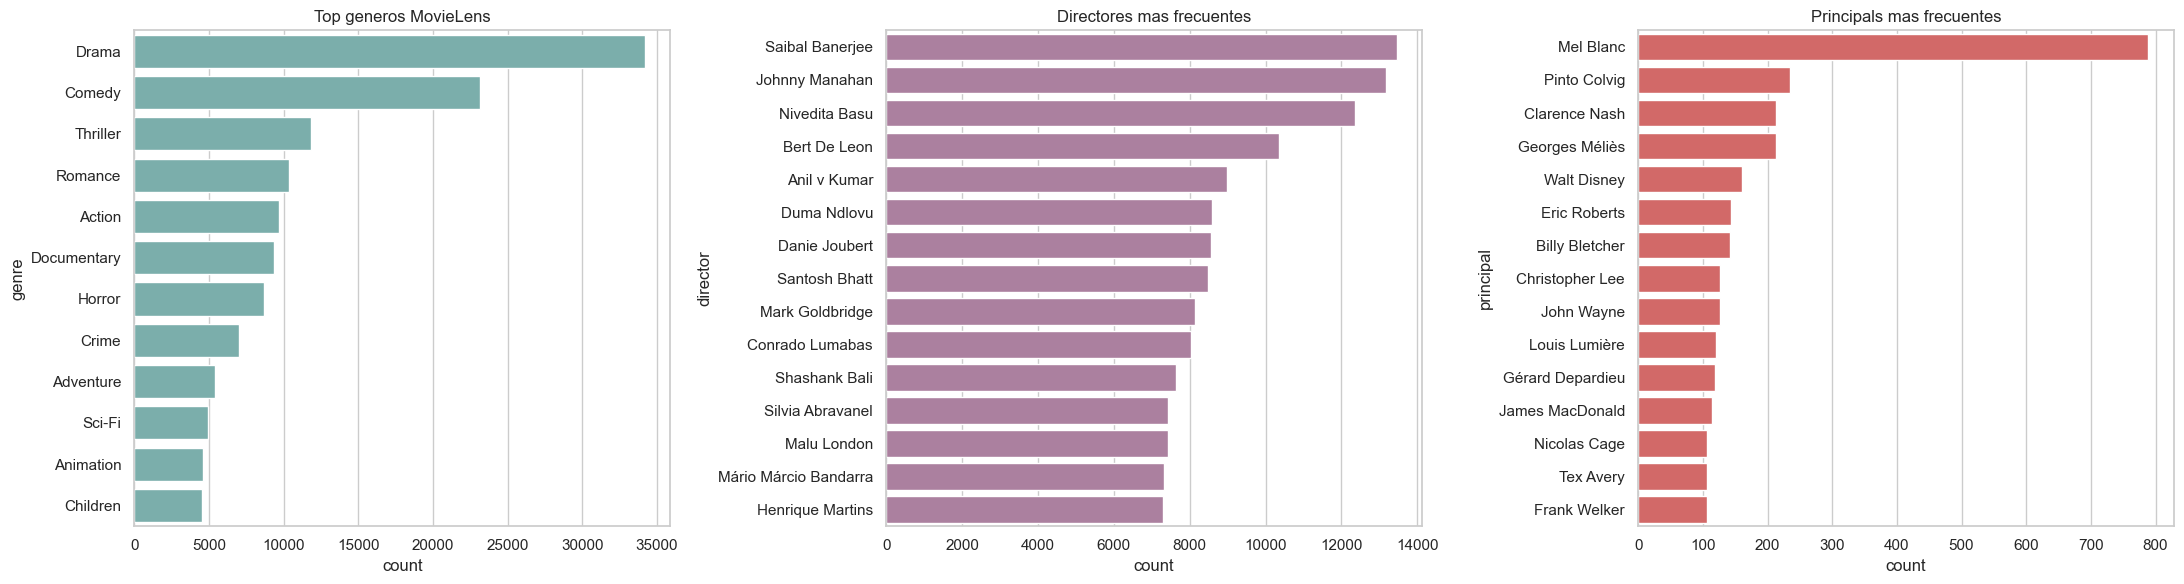

,feature,coverage
0,titleType,0.997420
5,principal_names,0.996483
2,averageRating,0.995867
3,numVotes,0.995867
4,directors_list,0.993001
1,runtimeMinutes,0.992111


In [5]:
genres_ml = items[['movieId', 'genres_movielens_list']].explode('genres_movielens_list').dropna()
genres_imdb = items[['movieId', 'genres_imdb_list']].explode('genres_imdb_list').dropna()

director_lookup = (
    imdb['title.crew'][['tconst', 'directors_list']]
    .explode('directors_list')
    .dropna(subset=['directors_list'])
    .merge(imdb['name.basics'][['nconst', 'primaryName']], left_on='directors_list', right_on='nconst', how='left')
)

director_counts = director_lookup['primaryName'].value_counts().head(15).rename_axis('director').reset_index(name='count')
principal_counts = (
    items[['movieId', 'principal_names']]
    .explode('principal_names')
    .dropna(subset=['principal_names'])
    ['principal_names']
    .value_counts()
    .head(15)
    .rename_axis('principal')
    .reset_index(name='count')
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.barplot(
    data=genres_ml['genres_movielens_list'].value_counts().head(12).rename_axis('genre').reset_index(name='count'),
    x='count', y='genre', ax=axes[0], color='#72B7B2'
)
axes[0].set_title('Top generos MovieLens')

sns.barplot(
    data=director_counts,
    x='count', y='director', ax=axes[1], color='#B279A2'
)
axes[1].set_title('Directores mas frecuentes')

sns.barplot(
    data=principal_counts,
    x='count', y='principal', ax=axes[2], color='#E45756'
)
axes[2].set_title('Principals mas frecuentes')

plt.tight_layout()
plt.savefig(figures_dir / 'eda_imdb_people_and_genres.png', bbox_inches='tight')
plt.show()

feature_quality = pd.DataFrame([
    {'feature': 'titleType', 'coverage': items['titleType'].notna().mean()},
    {'feature': 'runtimeMinutes', 'coverage': items['runtimeMinutes'].notna().mean()},
    {'feature': 'averageRating', 'coverage': items['averageRating'].notna().mean()},
    {'feature': 'numVotes', 'coverage': items['numVotes'].notna().mean()},
    {'feature': 'directors_list', 'coverage': items['directors_list'].apply(len).gt(0).mean()},
    {'feature': 'principal_names', 'coverage': items['principal_names'].apply(len).gt(0).mean()},
])
display(feature_quality.sort_values('coverage', ascending=False))
feature_quality.to_csv(tables_dir / 'imdb_feature_quality.csv', index=False)
